# Durchführung von Löschwasserberechnungen in PandaPipes (Hydranten werden auf Knoten gesetzt)

Im Rahmen meines Praktikums bei Gelsenwasser habe ich in die Open-Source-Rohrnetzberechnungssoftware Pandapipes die Funktion eingebaut, Löschwasserberechnungen durchzuführen. Dies wird im Folgenden anhand eines Beispiels erläutert. Zuerst müssen die notwendigen Funktionen importiert werden. In diesem Tutorial werden Hydranten betrachtet, die auf einen Knoten gesetzt werden. Es ist auch möglich sie auf ein Rohr zu setzen, beide Möglichkeiten können jedoch aktuell nicht gleichzeitig verwendet werden. Hier importieren wir deshalb `pandapipes.hydrants.hydrant_on_junction`.

In [1]:
import pandapipes as pp
from pandapipes.hydrants.hydrant_on_junction import *

Nun wird ein einfaches Netz mit einem externen Netz und einem Abnehmer erstellt. Zusätzlich können wir dieses plotten.

No or insufficient geodata available --> Creating artificial coordinates. This may take some time


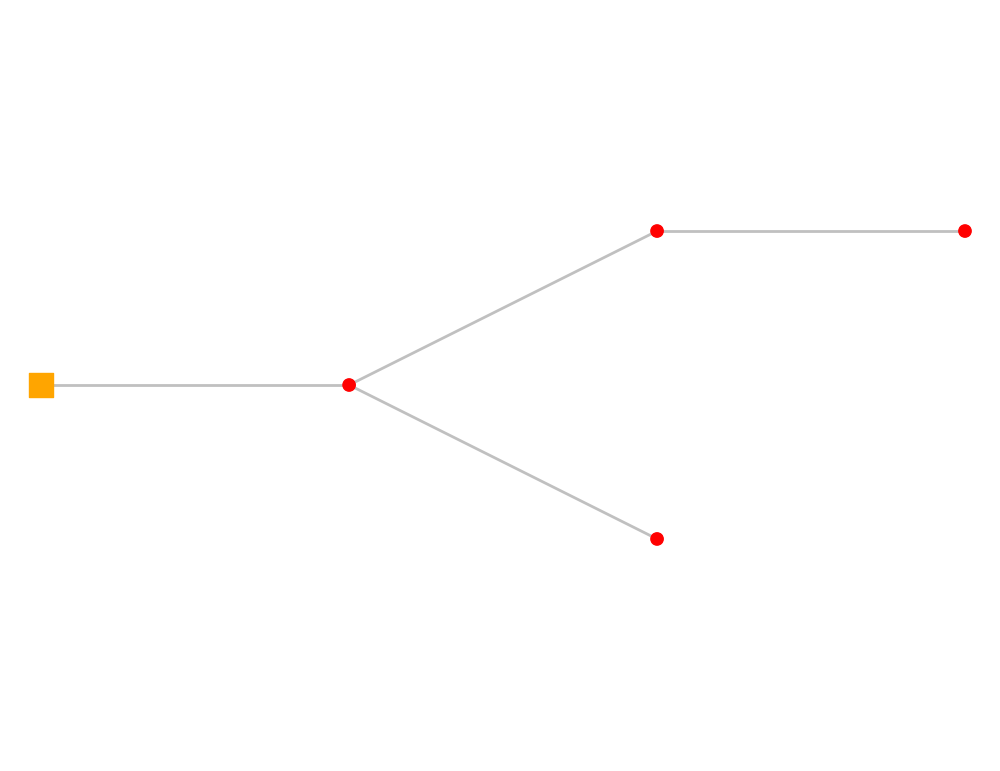

<Axes: >

In [2]:
net = pp.create_empty_network(fluid="water") 

#Erstellen der 5 Knoten
j0 = pp.create_junction(net, pn_bar=2, tfluid_k=293.15, name="Junction 1")
j1 = pp.create_junction(net, pn_bar=2, tfluid_k=293.15, name="Junction 2") 
j2 = pp.create_junction(net, pn_bar=2, tfluid_k=293.15, name="Junction 3")    
j3 = pp.create_junction(net, pn_bar=2, tfluid_k=293.15, name="Junction 4") 
j4 = pp.create_junction(net, pn_bar=2, tfluid_k=293.15, name="Junction 5") 

#Anbinden eines externen Netzes an den 1-ten und eines Abnehmers an den 4-ten Knoten
ext_grid = pp.create_ext_grid(net, junction=j0, p_bar=3, t_k=293.15, name="Grid Connection")
sink = pp.create_sink(net, junction=j4, mdot_kg_per_s=10, name="Sink")

#Erstellen der Rohre
p0 = pp.create_pipe_from_parameters(net, from_junction=j0, to_junction=j1, length_km=0.1, diameter_m=0.10, name="Pipe 1")
p1 = pp.create_pipe_from_parameters(net, from_junction=j1, to_junction=j2, length_km=0.1, diameter_m=0.10, name="Pipe 2")
p2 = pp.create_pipe_from_parameters(net, from_junction=j1, to_junction=j3, length_km=0.1, diameter_m=0.10, name="Pipe 3")
p3 = pp.create_pipe_from_parameters(net, from_junction=j3, to_junction=j4, length_km=0.01, diameter_m=0.10, name="Pipe 4")

#plotten des Netzes
from pandapipes.plotting import simple_plot
simple_plot(net)

Zum Vergleich berechnen wir das aktuelle Netz ohne Hydranten. Es ist zu sehen, dass der Druck am vierten Knoten mit 2,39 bar am niedrigsten ist. Dies ergibt natürlich Sinn, da das Wasser vom ersten Knoten zum letzten Knoten fließt, an dem der Abnehmer liegt.

In [3]:
#Berechnen des Netzes
pp.pipeflow(net, friction_model = "colebrook")
net.res_junction

,p_bar,t_k
0,3.000000,293.15
1,2.805874,293.15
2,2.805874,293.15
3,2.611747,293.15
4,2.592335,293.15


Nun können wir jeweils einen Hydranten auf die Knoten 1, 2 und 3 legen. Die Länge, der Druchmesser, die Rauhigkeit und der zusätzliche Verlustfaktor werden auf die Standardwerte gesetzt. Diese können jedoch auch mit übergeben werden. Die restlichen Felder sind für die Berechnung reserviert. Wir haben zwei Möglichkeiten Hydranten zu erstellen: Einzeln oder mehrere auf einmal. 

In [4]:
#Erstellen von zwei Hydranten: einzeln
create_hydrant(net, junction=1, name = "Hydrant 1")
create_hydrant(net, junction=2, name = "Hydrant 2")

#mehrere auf einmal
#create_hydrants(net, junctions = [1,2], name = ["Hydrant 1", "Hydrant 2"])

net.hydrant

,name,length_km,diameter_m,k_mm,loss_coefficient,in_service,hydrant_in_junction,hydrant_out_junction,hydrant_pipe,hydrant_sink
0,Hydrant 1,0.001,0.08,0.1,0.0,False,1,0,0,0
1,Hydrant 2,0.001,0.08,0.1,0.0,False,2,0,0,0


Nun wollen wir die Löschmengen für jeden Hydranten berechnen.
Für die exakte Löschmenge, die an einem Hydranten gezogen werden kann, benutzen wir die Funktion run_hydrant_flow_search. Es werden nun alle erstellten Hydranten durchgegangen und dort eine Löschmengenoptimierung durchgeführt. Es werden automatisch alle Hydraten nacheinander in das Netz eingefügt und entfernt. Die Rechnung kann mit `parallel = True` parallel ausgeführt werden, dies wird jedoch nur für eine große Anzahl an Hydranten empfohlen.

Am zweiten Hydranten können wir weniger Wasser entnehmen, da dieser am weitesten vom Abnehmer entfernt ist, sodass der Druckverlust bis dahin größer ist als bei dem anderen Hydranten.
Ein kritischer Knoten von -1 bedeutet, dass der niedrigste Netzdruck am Hydranten zu finden ist.

In [9]:
#Suchen der maximal möglichen Abnahme für jeden Hydranten
res = run_hydrant_flow_search(net, p_min = 1.5, parallel = False, friction_model = "colebrook")
res

,p_bar,t_k,mdot_kg_per_s,vdot_m3_per_h,min_p_bar,crit_junction,crit_p_bar
0,1.707809,293.15,15.638672,56.305966,1.499825,4.0,1.499825
1,1.499730,293.15,13.857422,49.892698,1.499730,-1.0,1.499730


Wollen wir jedoch für jeden Hydranten nur testen, welche die maximale Löschmenge aus einer Liste ist, die wir übergeben, ist die Funktion run_hydrant_flow_list die richtige.

In [10]:
#Suchen der maximalen Abnahme aus einer Liste für jeden Hydranten
res = run_hydrant_flow_list(net, flow_list = [192, 96, 48, 24, 0], flow_unit = "m3/h", p_min = 1.5, parallel = False, friction_model = "colebrook")
res

,p_bar,t_k,mdot_kg_per_s,vdot_m3_per_h,min_p_bar,crit_junction,crit_p_bar
0,1.928815,293.15,13.331736,48.0,1.717302,4.0,1.717302
1,1.576056,293.15,13.331736,48.0,1.576056,-1.0,1.576056


Zusätzlich ist es möglich einen Hydranten aus dem Netz zu löschen.

In [11]:
delete_hydrant(net, 0)
net.hydrant

,name,length_km,diameter_m,k_mm,loss_coefficient,in_service,hydrant_in_junction,hydrant_out_junction,hydrant_pipe,hydrant_sink
1,Hydrant 2,0.001,0.08,0.1,0.0,False,2,0,0,0
